In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from util import method_name_mapper, model_name_mapper, method_color_mapper, model_marker_mapper

In [2]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [3]:
plotdir = "/u/rfechner/verl/plots/data_driven"
os.makedirs(plotdir, exist_ok=True)

In [4]:
root = '/ptmp/rfechner/out/exp13_data_driven/'
paths = [
    os.path.join(root, p, 'val_jsonl') for p in os.listdir(root) if os.path.isdir(os.path.join(root, p))
]
paths

['/ptmp/rfechner/out/exp13_data_driven/eurollm_9b_instruct__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_7b__gspo/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/eurollm_9b_instruct__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_1.5b__gspo/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_7b__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_7b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/llama_3.1_8b_instruct__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/llama_3.1_8b_instruct__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_7b__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/llama_3.1_8b_instruct__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_1.5b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/qwen2.5_1.5b__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven/eurollm_9b_instruct__grpo-s/val_jsonl',
 '/ptmp/rfec

In [5]:
def gather_logprobs_with_percentile(path: str):
    checkpoint_results = []
    files = sorted(
        [x for x in os.listdir(path) if x.endswith("_precomp.jsonl")],
        key=lambda x: int(x.split("_")[0])
    )
    files = [files[0], files[-1]]
    print("Processing only first and last.")

    suffix_ks = np.arange(1, 10) / 10
    prefix_ks = np.arange(1, 10) / 10
    percentiles_p = np.array([0.01, 0.05, 0.1, 0.2])

    for file in files:
        filepath = os.path.join(path, file)
        print(f"Processing file: {filepath}")
        chunks = pd.read_json(filepath, lines=True, chunksize=10000)

        dfs = []
        for counter, chunk in enumerate(chunks):
            if counter % 10 == 0:
                print(f'File: {file}, Chunk: {counter}')

            # Convert list-of-logprobs to fixed object array for faster slicing
            logs = chunk["logprobs"].to_numpy()
            logs = np.array([np.asarray(row, dtype=float) for row in logs], dtype=object)

            # Preallocate result columns
            res = {
                "input_hash": chunk["input"].apply(hash).to_numpy(),
                "logprobs": np.array([x.mean() for x in logs]),
                "entropy": np.array([np.mean(e) for e in chunk["entropy"]]),
                "score": chunk["score"].to_numpy(),
                "checkpoint_global_step": chunk["checkpoint_global_step"].to_numpy(),
                "data_global_step": chunk["data_global_step"].to_numpy(),
            }

            # ----- Compute suffix & prefix logprob means (vectorized loop) -----
            for k in suffix_ks:
                name = f"suffix_{k}_logprobs"
                res[name] = np.array([
                    row[int(k * len(row)):].mean() if int(k * len(row)) > 0 else np.nan
                    for row in logs
                ])

            for k in prefix_ks:
                name = f"prefix_{k}_logprobs"
                res[name] = np.array([
                    row[:int(k * len(row))].mean() if int(k * len(row)) > 0 else np.nan
                    for row in logs
                ])

            # ----- Compute percentile means -----
            # Sorting each row once is dramatically faster
            sorted_logs = [np.sort(row) for row in logs]

            for p in percentiles_p:
                name = f"logprob_percentile_{p}"
                res[name] = np.array([
                    row[: int(p * len(row))].mean() if int(p * len(row)) > 0 else np.nan
                    for row in sorted_logs
                ])

            dfs.append(pd.DataFrame(res))

        checkpoint_results.append(pd.concat(dfs, ignore_index=True))

    return checkpoint_results


In [6]:
RELOAD = False
import pickle

if RELOAD:
    mapper = {}
    for path in paths:
        outs = gather_logprobs_with_percentile(path)
        mapper[path] = outs

    with open(os.path.join(root, 'cache.pickle'), 'wb') as file:
        pickle.dump(obj=mapper, file=file)
else:
    with open(os.path.join(root, 'cache.pickle'), 'rb') as file:
        mapper = pickle.load(file=file)

In [7]:
# VAL_FREQ = 10

# def plot_base_model_surprise(
#     experiment_name: str,
#     outs: list[pd.DataFrame],
#     plotname_prefix: str | None = None,
# ) -> None:
#     """
#     Plot surprise (negative log-likelihood) of the base model
#     for whole trajectories at k = {0.1, 0.5, 0.9}.
#     """
#     base_df, _ = outs
#     cmap = plt.get_cmap("viridis", 3) # 0.1-suffix 0.1-prefix whole trajectory.

#     # ---------- compute stats ----------
#     def compute_stats(df, colname):
#         means = []
#         groups = df.groupby("data_global_step", sort=True)
#         for _, group in groups:
#             arr = group[colname].to_numpy()
#             means.append(np.nanmean(arr))
#         return means

#     # ---------- FIGURE ----------
#     fig, ax = plt.subplots(figsize=(6.5, 4))
#     keys = ['logprobs', 'suffix_0.1_logprobs', 'prefix_0.1_logprobs']
#     for i, col in enumerate(keys):
#         vals = compute_stats(base_df, col)
#         xs = np.arange(0, len(vals) * VAL_FREQ, VAL_FREQ)
#         color = cmap(i)

#         # Surprise = -log p(x | θ)
#         ax.plot(
#             xs,
#             -np.array(vals),
#             label=col,
#             color=color,
#         )

#     ax.set_xlabel(
#         r"\textbf{Source checkpoint training step}",
#         fontsize=11,
#     )
#     ax.set_ylabel(
#         r"\textbf{Surprise} $-\log p(x \mid \theta_{\mathrm{base}})$",
#         fontsize=12,
#     )

#     model, method = experiment_name.split("__")
#     ax.set_title(
#         rf"Base model trajectory surprise \quad "
#         rf"\textbf{{Model:}} {model}, \textbf{{Method:}} {method}",
#         fontsize=13,
#     )

#     ax.legend(fontsize=10)
#     ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(
#         os.path.join(
#             plotdir,
#             f"{plotname_prefix + '-' if plotname_prefix else ''}"
#             f"{experiment_name}_base_surprise.pdf",
#         ),
#         dpi=300,
#         bbox_inches="tight",
#     )
#     plt.show()
# for name in mapper.keys():
#     expname = pathlib.Path(name).parts[-2]
#     plot_base_model_surprise(expname, mapper[name], plotname_prefix='base_surprise-')

In [20]:
VAL_FREQ = 10
from typing import Any

def plot_model_surprise_single_plot(
    mapper: dict[str, Any],
    take_base_model: bool = True,
) -> None:
    checkpoint_i = 0 if take_base_model else -1
    model_type = "base" if take_base_model else "RL"
    title = (
        r"Mean Surprise $:= - \frac{1}{|\mathcal X_i|} \sum_{x \in \mathcal X_i} "
        rf"\log p(x \mid \theta_{{\mathrm{{{model_type}}}}})$ for different base models"
    )

    methods = sorted({k.split("__")[1].removesuffix("/val_jsonl") for k in mapper})
    def compute_stats(df, col="logprobs"):
        return [
            np.nanmean(g[col].to_numpy())
            for _, g in df.groupby("data_global_step", sort=True)
        ]

    models = [
        ("qwen2.5_1.5b", "Qwen2.5-1.5B"),
        ("qwen2.5_7b", "Qwen2.5-7B"),
        ("llama_3.1_8b_instruct", "Llama3.1-8B-Instruct"),
        ("eurollm", "EuroLLM-9B"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    for ax, (model_key, title_name) in zip(axes, models):
        for k, v in mapper.items():
            if model_key not in k:
                continue
            _, method = k.split("__")
            method = method.removesuffix("/val_jsonl")
            vals = compute_stats(v[checkpoint_i])
            xs = np.arange(0, len(vals) * VAL_FREQ, VAL_FREQ)
            ax.plot(xs, -np.array(vals), label=method_name_mapper[method], color=method_color_mapper[method])

        ax.set_title(title_name)
        ax.set_xlabel(r"$\mathcal X_i$ Source checkpoint", fontsize=11)
        ax.set_ylabel("Surprise", fontsize=12)
        ax.grid(alpha=0.3)

    axes[-1].legend(fontsize=10, bbox_to_anchor=(1.9, 1), loc="upper right")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(
        os.path.join(plotdir, f"comparison_base_surprise-{model_type}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


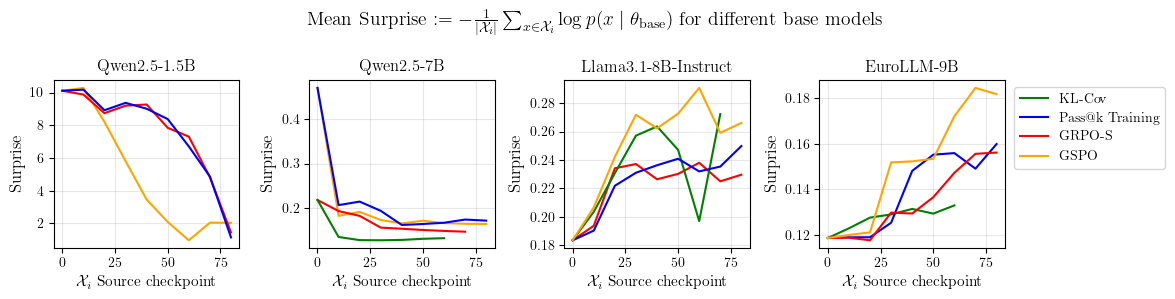

In [21]:
plot_model_surprise_single_plot(mapper)

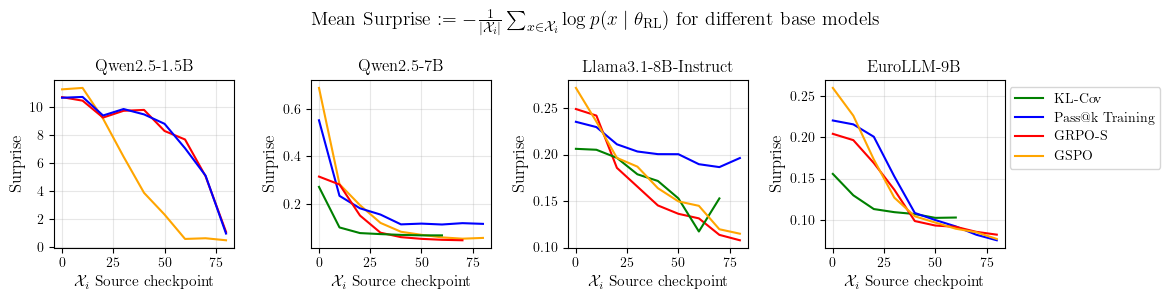

In [22]:
plot_model_surprise_single_plot(mapper, take_base_model=False)

In [27]:
def plot_model_prefix_suffix_single_plot(
    mapper: dict[str, Any],
    take_base_model: bool = True,
) -> None:
    checkpoint_i = 0 if take_base_model else -1
    model_type = "base" if take_base_model else "RL"
    title = (
        r"Mean Prefix / Suffix Surprise "
        rf"$(-\log p(x \mid \theta_{{\mathrm{{{model_type}}}}}))$"
    )

    methods = sorted({k.split("__")[1].removesuffix("/val_jsonl") for k in mapper})
    def compute_stats(df, col):
        return [
            np.nanmean(g[col].to_numpy())
            for _, g in df.groupby("data_global_step", sort=True)
        ]

    models = [
        ("qwen2.5_1.5b", "Qwen2.5-1.5B"),
        ("qwen2.5_7b", "Qwen2.5-7B"),
        ("llama_3.1_8b_instruct", "Llama3.1-8B-Instruct"),
        ("eurollm", "EuroLLM-9B"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    for ax, (model_key, title_name) in zip(axes, models):
        for k, v in mapper.items():
            if model_key not in k:
                continue

            _, method = k.split("__")
            method = method.removesuffix("/val_jsonl")
            df = v[checkpoint_i]

            prefix_vals = compute_stats(df, "prefix_0.1_logprobs")
            suffix_vals = compute_stats(df, "suffix_0.1_logprobs")
            xs = np.arange(0, len(prefix_vals) * VAL_FREQ, VAL_FREQ)

            ax.plot(
                xs,
                -np.array(prefix_vals),
                color=method_color_mapper[method],
                linestyle="-",
                label=f"{method_name_mapper[method]} (prefix)",
            )
            ax.plot(
                xs,
                -np.array(suffix_vals),
                color=method_color_mapper[method],
                linestyle="--",
                label=f"{method_name_mapper[method]} (suffix)",
            )

        ax.set_title(title_name)
        ax.set_xlabel(r"$\mathcal X_i$ Source checkpoint", fontsize=11)
        ax.set_ylabel("Surprise", fontsize=12)
        ax.grid(alpha=0.3)

    axes[-1].legend(fontsize=9, bbox_to_anchor=(2.2, 1), loc="upper right")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(
        os.path.join(plotdir, f"comparison_prefix_suffix_surprise-{model_type}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


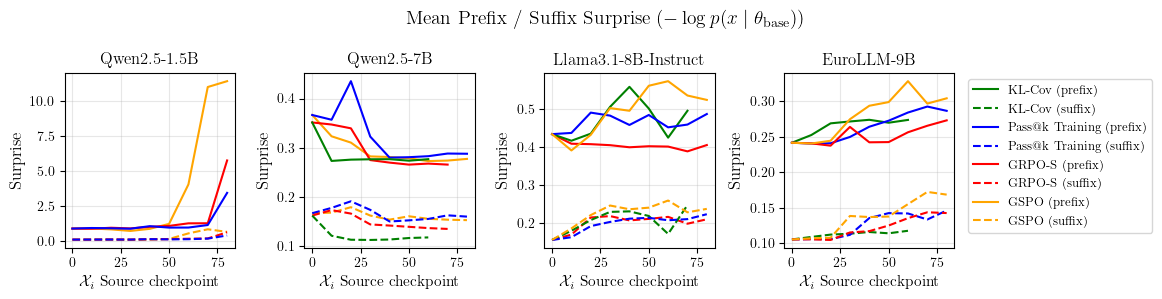

In [28]:
plot_model_prefix_suffix_single_plot(mapper)

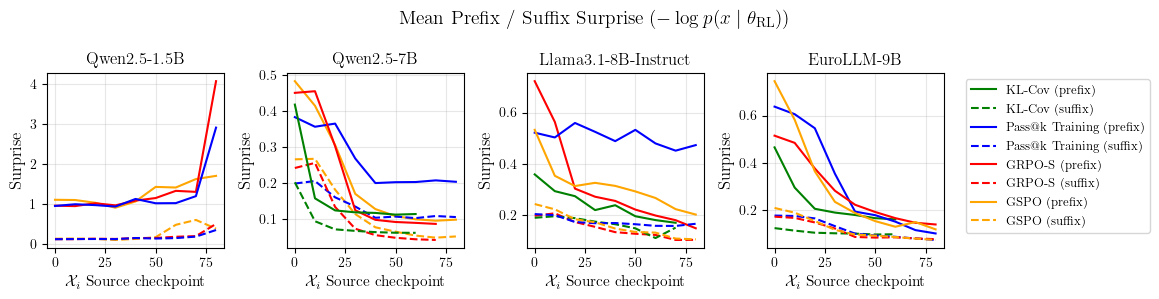

In [29]:
plot_model_prefix_suffix_single_plot(mapper, take_base_model=False)

In [30]:
# VAL_FREQ = 10
# K_VALUES = np.arange(1, 10) / 10

# def plot_prefix_suffix(experiment_name: str, outs: list[pd.DataFrame], plotname_prefix=None) -> None:
#     first, last = outs

#     cmap = plt.get_cmap('viridis', len(K_VALUES))

#     # ---------- compute stats ----------
#     def compute_stats(df, colname):
#         values, stds = [], []
#         groups = df.groupby("data_global_step", sort=True)
#         for _, group in groups:
#             arr = group[colname].to_numpy()
#             values.append(np.nanmean(arr))
#             stds.append(np.nanstd(arr))
#         return values, stds

#     # ---------- FIGURE ----------
#     fig, (ax1, ax2) = plt.subplots(
#         nrows=1, ncols=2, sharey=False, figsize=(12, 4)
#     )

#     # ==========================================================
#     # ===================== SUFFIX PLOT =========================
#     # ==========================================================

#     for i, k in enumerate(K_VALUES):
#         col = f"suffix_{k}_logprobs"
#         first_vals, _ = compute_stats(first, col)
#         last_vals, _  = compute_stats(last, col)

#         xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
#         xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

#         color = cmap(i)
#         ax1.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
#                      color=color, linestyle="--")
#         ax1.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
#                      color=color)

#     ax1.set_ylabel(r"$p(x[k \cdot N:] \mid \theta_j)$", fontsize=12)
#     ax1.set_xlabel(r"$x[k \cdot N:]$ \textbf{ source checkpoint training step}", fontsize=11)
#     ax1.set_title(r"Suffix likelihoods $p(x[k \cdot N:] \mid \theta_j)$", fontsize=13)

#     # ==========================================================
#     # ===================== PREFIX PLOT =========================
#     # ==========================================================

#     for i, k in enumerate(K_VALUES):
#         col = f"prefix_{k}_logprobs"
#         first_vals, _ = compute_stats(first, col)
#         last_vals, _  = compute_stats(last, col)

#         xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
#         xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

#         color = cmap(i)
#         ax2.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
#                      color=color, linestyle="--")
#         ax2.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
#                      color=color)

#     ax2.set_ylabel(r"$p(x[:k\cdot N] \mid \theta_j)$", fontsize=12)
#     ax2.set_xlabel(r"$x[:k\cdot N]$ \textbf{ source checkpoint training step}", fontsize=11)
#     ax2.set_title(r"Prefix likelihoods  $p(x[:k\cdot N] \mid \theta_j)$", fontsize=13)

#     # ---------- Title ----------
#     model, method = experiment_name.split("__")
#     plt.suptitle(
#         rf"Log-likelihoods of subsequences, Normalized by Sequence Length; \quad \textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
#         fontsize=14
#     )

#     # ---------- Legend ----------
#     plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)

#     plt.savefig(os.path.join(plotdir, f"{plotname_prefix + '-' if plotname_prefix else ''}{experiment_name}_prefix_suffix_plot.pdf"), dpi=300, bbox_inches="tight")
#     plt.tight_layout()
#     plt.show()
# for name in mapper.keys():
#     expname = pathlib.Path(name).parts[-2]
#     plot_prefix_suffix(expname, mapper[name], plotname_prefix='seqlen_normalized_k-')

In [ ]:
# P_VALUES = np.array([0.01, 0.05, 0.1, 0.2])
# def plot_percentiles(experiment_name: str, outs: list[pd.DataFrame], plotname_prefix=None) -> None:
#     first, last = outs

#     cmap = plt.get_cmap('viridis', len(P_VALUES))

#     # ---------- compute stats ----------
#     def compute_stats(df, colname):
#         values, stds = [], []
#         groups = df.groupby("data_global_step", sort=True)
#         for _, group in groups:
#             arr = group[colname].to_numpy()
#             values.append(np.nanmean(arr))
#             stds.append(np.nanstd(arr))
#         return values, stds

#     # ---------- FIGURE ----------
#     fig, ax1 = plt.subplots(
#         nrows=1, ncols=1, sharey=False, figsize=(6, 4)
#     )

#     for i, p in enumerate(P_VALUES):
#         col = f"logprob_percentile_{p}"
#         first_vals, _ = compute_stats(first, col)
#         last_vals, _  = compute_stats(last, col)

#         xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
#         xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

#         color = cmap(i)
#         ax1.errorbar(xs_first, first_vals, label=fr"$p={p},\,\theta_{{base}}$", 
#                      color=color, linestyle="--")
#         ax1.errorbar(xs_last, last_vals, label=fr"$p={p},\,\theta_{{RL}}$", 
#                      color=color)

#     ax1.set_ylabel(r"\textbf{Mean Logprob}", fontsize=12)
#     ax1.set_xlabel(r"\textbf{Source checkpoint training step}", fontsize=12)
    
#     # ---------- Title ----------
#     model, method = experiment_name.split("__")
#     plt.suptitle(
#         rf"Log-likelihoods of p-percentiles; \quad \textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
#         fontsize=14
#     )

#     # ---------- Legend ----------
#     plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)

#     plt.savefig(os.path.join(plotdir, f"{plotname_prefix + '-' if plotname_prefix else ''}{experiment_name}_percentiles.pdf"), dpi=300, bbox_inches="tight")
#     plt.tight_layout()
#     plt.show()
#for name in mapper.keys():
#     expname = pathlib.Path(name).parts[-2]
#     plot_percentiles(expname, mapper[name])

In [4]:
# "Across" view: I'd like to just plot a surprise matrix, where we dim 0 is evaluator model, dim 1 is generator model.
across_root = '/ptmp/rfechner/out/exp13_data_driven_across'
dirs = [os.path.join(across_root, d, 'val_jsonl') for d in os.listdir(across_root) if not d.endswith('pickle')]
dirs

['/ptmp/rfechner/out/exp13_data_driven_across/eurollm_9b_instruct__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_7b__gspo/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/eurollm_9b_instruct__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_1.5b__gspo/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_7b__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_7b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/llama_3.1_8b_instruct__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/llama_3.1_8b_instruct__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_7b__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/llama_3.1_8b_instruct__grpo-passk/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_1.5b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp13_data_driven_across/qwen2.5_1.5b__grpo-passk/val_jsonl',
 '/ptmp

In [5]:
def gather_logprobs_across(path: str) -> dict[str, float]:
    if len(os.listdir(path)) > 1:
        raise ValueError("Found more than one file in path: " + path)
    filepath = os.path.join(path, os.listdir(path)[0])

    print(f"Processing file: {filepath}")
    chunks = pd.read_json(filepath, lines=True, chunksize=10000)

    dfs = []
    for counter, chunk in enumerate(chunks):
        if counter % 10 == 0:
            print(f'File: {filepath}, Chunk: {counter}')

        # Convert list-of-logprobs to fixed object array for faster slicing
        logs = chunk["logprobs"].to_numpy()
        logs = np.array([np.asarray(row, dtype=float) for row in logs], dtype=object)

        # Preallocate result columns
        res = {
            "logprobs": np.array([x.mean() for x in logs]),
            "model" : chunk['model'],
            "method" : chunk['method']
        }
        dfs.append(pd.DataFrame(res))
    ret = pd.concat(dfs, axis=0)
    ret['model_method_key'] = [model + '__' + method for model, method in zip(ret['model'], ret['method'])]
    ret_dict = {}
    for model_method_key, df in ret.groupby('model_method_key', sort=False):
        mean_surprise = -np.mean(df['logprobs'])
        ret_dict[model_method_key] = mean_surprise.item()
    return ret_dict


In [6]:
from pathlib import Path
import os
import pickle
RELOAD=False
if RELOAD:
    matrix = {}
    for d in dirs:
        mmkey = Path(d).parts[-2]
        matrix[mmkey] = gather_logprobs_across(d)
    
    with open(os.path.join(across_root, 'cache.pickle'), 'wb') as file:
        pickle.dump(matrix, file)
else:
    with open(os.path.join(across_root, 'cache.pickle'), 'rb') as file:
        matrix = pickle.load(file)

In [19]:
def plot_mean_surprise_heatmap(mean_surprises: dict[str, dict[str, float]], filter_methods : None | list[str] = None, filter_models : None | list[str] = None, annotate=False) -> None:
    # --- sort axes ---
    row_keys = sorted(mean_surprises.keys())
    col_keys = sorted(
        {k for inner in mean_surprises.values() for k in inner.keys()}
    )
    if filter_methods:
        row_keys = list(filter(lambda x: all([me not in x for me in filter_methods]), row_keys))
        col_keys = row_keys
    
    if filter_models:
        row_keys = list(filter(lambda x: all([mo not in x for mo in filter_models]), row_keys))
        col_keys = row_keys
        

    # --- build matrix ---
    data = np.full((len(row_keys), len(col_keys)), np.nan)
    for i, r in enumerate(row_keys):
        for j, c in enumerate(col_keys):
            if c in mean_surprises[r]:
                data[i, j] = mean_surprises[r][c]

    # --- plot ---
    fig, ax = plt.subplots(figsize=(0.8 * len(col_keys), 0.6 * len(row_keys)))
    im = ax.imshow(data, aspect="auto")

    # ticks & labels
    ax.set_xticks(np.arange(len(col_keys)))
    ax.set_yticks(np.arange(len(row_keys)))
    ax.set_xticklabels(col_keys, rotation=45, ha="right")
    ax.set_yticklabels(row_keys)

    if annotate:
        # annotate cells
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                if not np.isnan(data[i, j]):
                    ax.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", fontsize=9)

    ax.set_ylabel('Evaluator model', fontsize=14)
    ax.set_xlabel('Generator model', fontsize=14)
    ax.set_title("Mean Surprise Across RL-Trained Models")
    fig.colorbar(im, ax=ax, label="Mean Surprise")
    plt.savefig(os.path.join(plotdir, f"surprise_across.pdf"), dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()


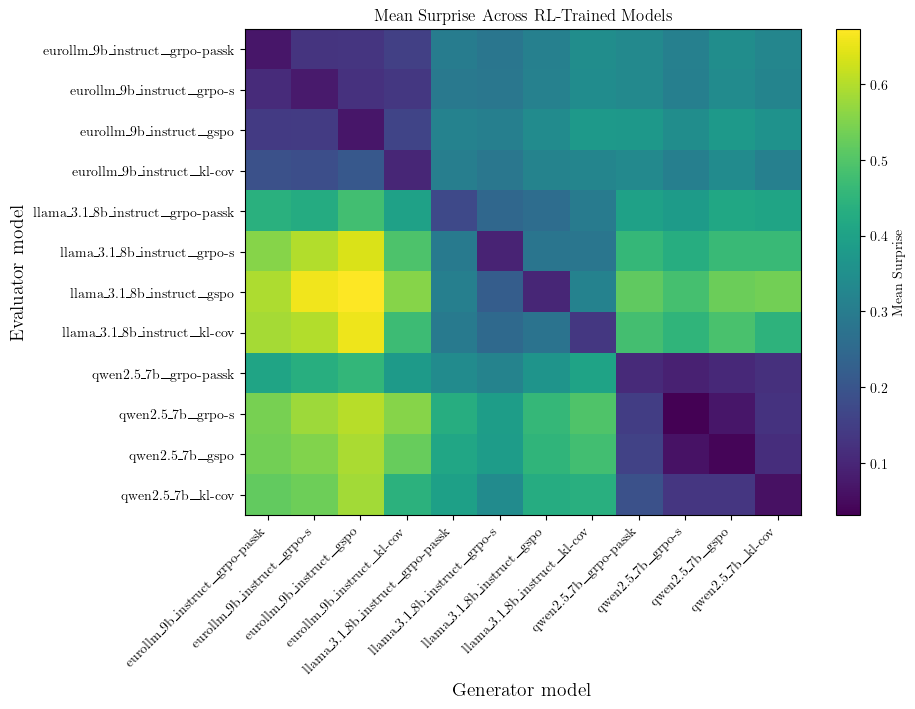

In [20]:
plot_mean_surprise_heatmap(matrix, filter_models=['qwen2.5_1.5b'])